In [1]:
import numpy as np

import matplotlib.pyplot as plt

from response_stats.pipeline import *

rng = np.random.default_rng()

0.1
1.0
2.0
3.0
4.0
5.0
8.0
10.0
12.0
15.0


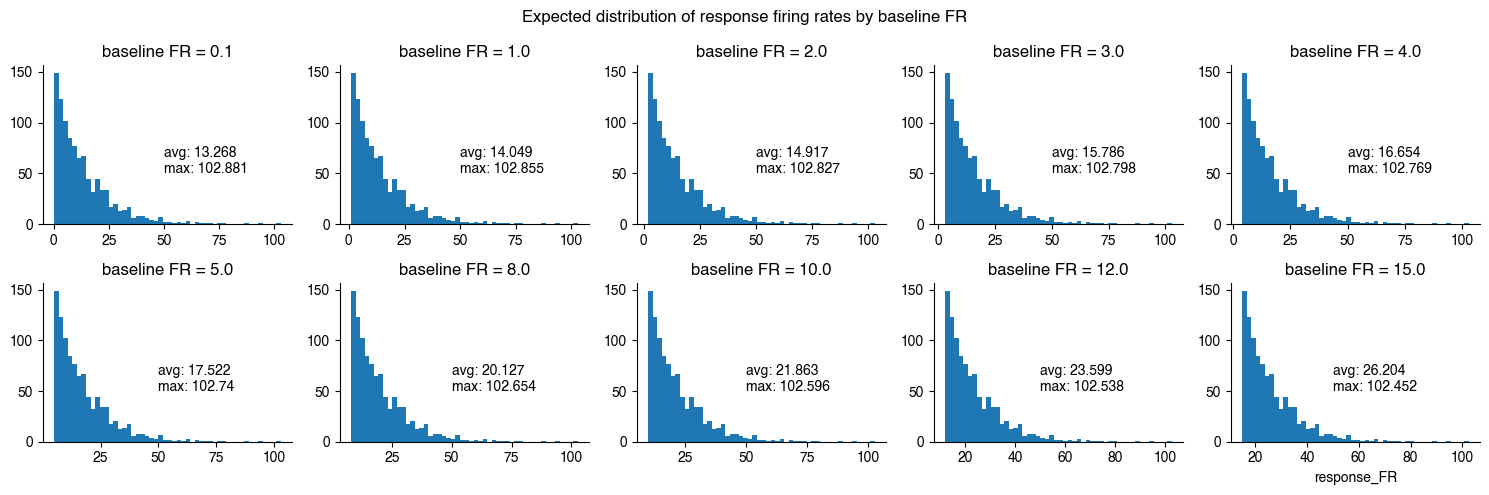

In [ ]:
def harmonic_number(n):
    return np.sum(1 / np.arange(1, n+1))

def calculate_scale(n, threshold, target_max):
    return (target_max - threshold) / harmonic_number(n)

rng = np.random.default_rng()

u = rng.uniform(size=1000)

x = np.array([0.1, 1, 2, 3, 4, 5, 8, 10, 12, 15])
y = 2 * x + 3

fig, axes = plt.subplots(2,5,figsize=(15,5))
axes = axes.flatten()

for i, ax in enumerate(axes):

    print(x[i])
    threshold = x[i]
    scale = calculate_scale(len(u), threshold, 100)

    f = threshold - scale * np.log(u)
    ax.hist(f, bins=50)
    ax.text(50, 50, f"avg: {round(np.mean(f), 3)}\nmax: {round(np.max(f), 3)}")
    ax.set_title(f"baseline FR = {x[i]}")
    sns.despine(ax=ax)
plt.xlabel("response_FR")

plt.suptitle("Expected distribution of response firing rates by baseline FR")
plt.tight_layout()
plt.show()

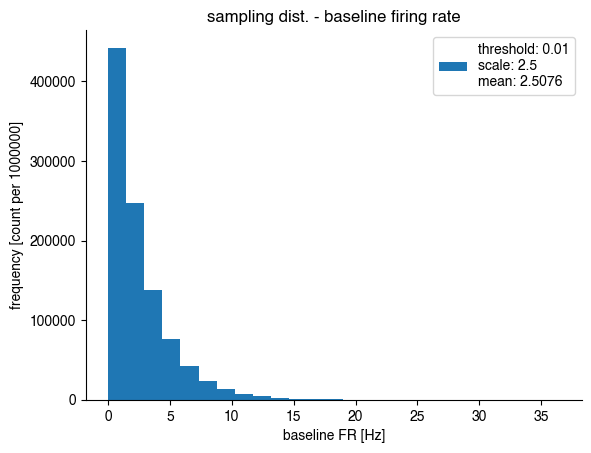

In [428]:
rng = np.random.default_rng()
size=1*10**6
u = rng.uniform(size=size)

scale = 2.5
threshold = 0.01
f =threshold - scale * np.log(u)

plt.hist(f, bins=25, label=f"threshold: {threshold}\nscale: {scale}\nmean: {round(np.mean(f),4)}")
plt.title("sampling dist. - baseline firing rate")
plt.xlabel("baseline FR [Hz]")
plt.ylabel(f"frequency [count per {size}]")
plt.legend()
sns.despine()
plt.show()

In [ ]:
beta_a_range = [1, 1.5]

a_ = rng.uniform(low=beta_a_range[0], high=beta_a_range[1], size=1000)
plt.hist(a_, bins=25)
plt.show()

In [ ]:
def estimate_alpha(u, v):
    return u * ((u*(1-u) / v) - 1)

def estimate_beta(u, v):
    return (1 - u) * ((u* (1-u) / v) - 1)

In [ ]:
mtl_mean_2008 = np.mean([271, 392, 394, 397])
pooled_mean = np.mean(mtl_mean_2008)

sem_phc = (288 - 254) / 2 
sem_ec = (409 - 375) / 2
sem_hp = (406 - 383) / 2
sem_a = (410 - 383) / 2

n_phc = 47
n_ec = 79
n_hp = 171
n_a = 101
n_all = np.array([n_phc, n_ec, n_hp, n_a])

var_phc = sem_phc**2 * n_phc
var_ec = sem_ec**2 * n_ec
var_hp = sem_hp**2 * n_hp
var_a = sem_a**2 * n_a
var_all = np.array([var_phc, var_ec, var_hp, var_a])

pooled_var = np.sum((n_all - 1) * var_all) / np.sum(n_all - 1)

In [ ]:
estimate_alpha(pooled_mean, pooled_var)

In [ ]:
a = 1.056
b = 5.831
s = 1000_000

sample = rng.beta(a=a, b=b, size=s)
print(np.min(sample))
print(np.mean(sample))
print(np.max(sample))
plt.hist(sample, 25)
plt.show()

In [ ]:
cfg_path = Path("/home/al/Documents/code/generate_responses/configs/main_dataset/[401,500]_response.yaml")

cfg = SimulationConfig.from_yaml(cfg_path)

def exp_dist(scale, threshold, rng=rng):
    u = rng.uniform(size=1000)
    return threshold - scale * np.log(u)

def plot_dist(x, x_label, y_label, title, bins=25):
    plt.hist(x, bins=bins)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    sns.despine()
    plt.show()


In [ ]:
cfg.baseline_threshold and cfg.baseline_scale

In [ ]:
baseline_dist = exp_dist(cfg.scale, cfg.threshold)

plot_dist(baseline_dist, "baseline FR [Hz]", "count", "baseline FR distribution - 1k version")

low = 0.1
high = 15
baseline_dist = rng.uniform(low=low, high=high, size=1000)

plot_dist(baseline_dist, "baseline FR [Hz]", "count", "baseline FR distribution - new version")

In [ ]:
response_gain_dist = exp_dist(cfg.gain_response_fr_scale, cfg.gain_response_fr_threshold)

plot_dist(response_gain_dist, "gain in FR [Hz]", "count", "ratio of response FR to baseline FR - 1k version")

scale = 1
threshold = 5
response_gain_dist = exp_dist(scale, threshold)

plot_dist(response_gain_dist, "gain in FR [Hz]", "count", "ratio of response FR to baseline FR - new version")

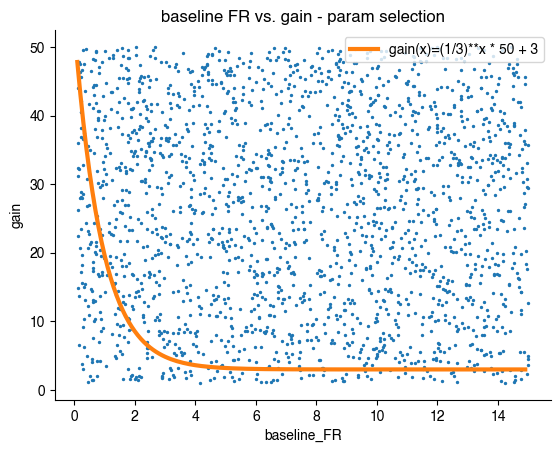

In [17]:
size = 2000
x_label = "baseline_FR"
y_label = "gain"
title = "baseline FR vs. gain - param selection"

low = 0.1
high = 15
baseline_dist = rng.uniform(low=low, high=high, size=size)

gain_high = 50
gain_dist = rng.uniform(low=1, high=gain_high, size=size)



e = 3
b = gain_high
y = 3

x = np.arange(low,high, 0.1)
f = (1/y)**x * b + e
t = f"gain(x)=(1/{round(y, 3)})**x * {round(b,3)} + {e}"


max_fr = 100
m = max_fr / x


plt.scatter(baseline_dist, gain_dist, s=2)
plt.plot(x, f, color="tab:orange", lw=3, label=t)
#plt.plot(x, m, color="tab:red")

plt.legend(loc="upper right")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
sns.despine()
plt.show()

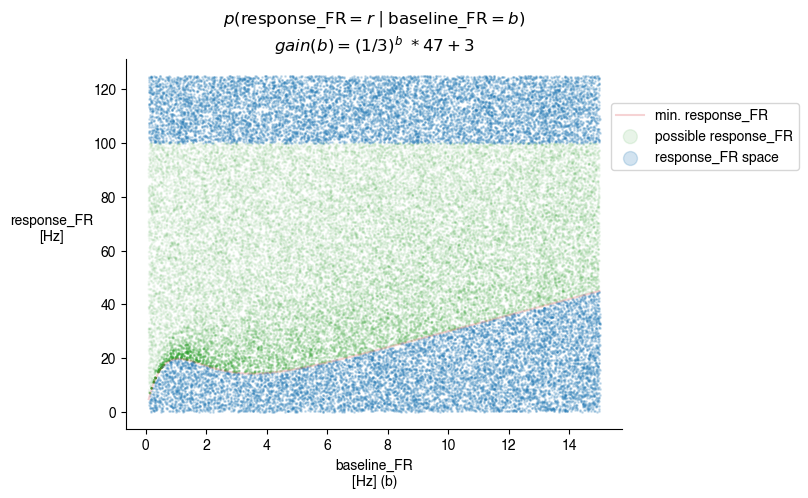

In [431]:
def gain_function(x, y=3, gain_high=50, e=3):
    return (1/y)**x * gain_high + e

def cdf_response(r, b, scale=1):
    g = gain_function(b)
    r_min = g * b
    z = (r / b - g) / scale
    return np.where(r < r_min, 0, 1 - np.exp(-z))

def interval_prob(r1, r2, b, scale=1):
    return np.clip(cdf_response(r2, b, scale) - cdf_response(r1, b, scale), 0, 1)

size = 50_000

max_fr = 100

# low = 0.1
# high = 15
# baseline_dist = rng.uniform(low=low, high=high, size=size)

u = rng.uniform(size=size)
scale = 2.5
threshold = 0.01
f =threshold - scale * np.log(u)

low_r = 0.1
high_r = 125
response_dist = rng.uniform(low=low_r, high=high_r, size=size)

# thresholds
y = 3
gain_high = 50
e = 3
gains = gain_function(baseline_dist, y, gain_high, e)

# response FRs that would be accepted
mask = (response_dist >= baseline_dist * gains) & (response_dist <= max_fr)

x = np.arange(low, high, 0.01)
y = gain_function(x) * x
plt.plot(x,y, color="tab:red", label="min. response_FR", alpha=0.2)

####
# set alpha for each point = likelihood of a particular response_Fr given the baseline_FR
delta = 2
scale = 3

p_bin = interval_prob(response_dist[mask], response_dist[mask] + 1, baseline_dist[mask], scale)

alpha_vals = p_bin / (p_bin.max() + 1e-10)
alpha_min = 0.05
alpha_max = 1
alpha_vals = alpha_min + (alpha_max - alpha_min) * alpha_vals
alpha_vals = np.clip(alpha_vals, 0, 1)
####


plt.scatter(
    baseline_dist[mask],
    response_dist[mask],
    s=1,
    color="tab:green",
    alpha=alpha_vals,
    label="possible response_FR"
)

inverse_mask = mask != True
plt.scatter(baseline_dist[inverse_mask], response_dist[inverse_mask], s=1, alpha=0.2, label="response_FR space")



plt.xlabel("baseline_FR\n[Hz] (b)")
plt.ylabel("response_FR\n[Hz]", rotation=0, labelpad=30)


plt.title(
    r"$p(\mathrm{response\_FR}=r \mid \mathrm{baseline\_FR}=b)$"
    "\n"
    r"$gain(b) = (1/3)^b\ * 47 + 3$"
)


plt.legend(
    markerscale=10,
    loc="upper right",
    bbox_to_anchor=(1.37, .9)
)


sns.despine()
plt.show()

11

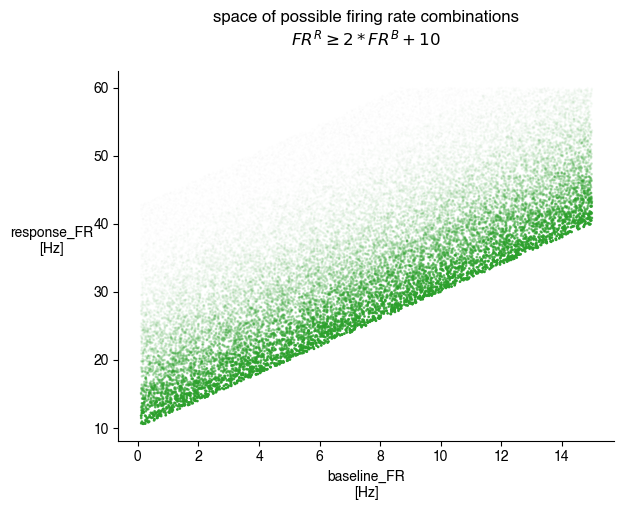

In [458]:
def response_curve(b, slope, offset):
    return b * slope + offset

def cdf_response(r, b, slope, offset, scale=1):
    r_min = response_curve(b, slope, offset)

    z = (r / b - r_min) / scale
    return np.where(r < r_min, 0, 1 - np.exp(-z))

def interval_prob(r1, r2, b, slope, offset, scale=1):
    return np.clip(cdf_response(r2, b, slope, offset, scale) - cdf_response(r1, b, slope, offset, scale), 0, 1)

def pdf_response(r, b, slope, offset, scale=1.0):
    """p(r | b) (density), with R = mu(b) + Exp(scale)."""
    mu = response_curve(b, slope, offset)
    z = (r - mu) / scale
    return np.where(r < mu, 0.0, (1.0 / scale) * np.exp(-z))

size = 50_000

max_fr = 60

min_fr = 10
slope = 2

low = 0.1
high = 15
baseline_dist = rng.uniform(low=low, high=high, size=size)

low_r = 0.1
high_r = max_fr
response_dist = rng.uniform(low=low_r, high=high_r, size=size)

r_accepted = response_curve(baseline_dist, slope, min_fr)

# response FRs that would be accepted
mask = (response_dist >= r_accepted)

# ####
# # set alpha for each point = likelihood of a particular response_Fr given the baseline_FR
# delta = 2
# scale = 3

# p_bin = interval_prob(response_dist[mask], response_dist[mask] + 1, baseline_dist[mask], slope, min_fr, scale)

# alpha_vals = p_bin / (p_bin.max() + 1e-10)
# alpha_min = 0.05
# alpha_max = 1
# alpha_vals = alpha_min + (alpha_max - alpha_min) * alpha_vals
# alpha_vals = np.clip(alpha_vals, 0, 1)
# ####


scale = 5
lik = pdf_response(response_dist[mask], baseline_dist[mask], slope, min_fr, scale=scale)

alpha_vals = lik / (lik.max() + 1e-12)
alpha_min, alpha_max = 0.0005, 1.0
alpha_vals = alpha_min + (alpha_max - alpha_min) * alpha_vals
alpha_vals = np.clip(alpha_vals, 0, 1)


plt.scatter(
    baseline_dist[mask],
    response_dist[mask],
    s=1,
    color="tab:green",
    alpha=alpha_vals,
    label="possible response_FR"
)

plt.xlabel("baseline_FR\n[Hz]")
plt.ylabel("response_FR\n[Hz]", rotation=0, labelpad=30)


plt.title(
    r"space of possible firing rate combinations"
    "\n"
    r"$FR^{R} \geq 2*FR^{B} + 10$"
    "\n"

)

sns.despine()
plt.show()

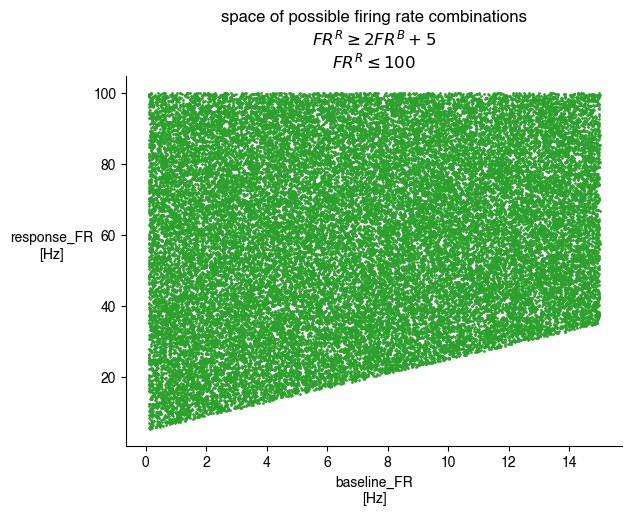

In [ ]:
def response_curve(b, slope, offset):
    return b * slope + offset


size = 50_000

min_fr = 5
max_fr = 100
slope = 2

low = 0.1
high = 15
baseline_dist = rng.uniform(low=low, high=high, size=size)

low_r = 0.1
high_r = max_fr
response_dist = rng.uniform(low=low_r, high=high_r, size=size)

r_accepted = response_curve(baseline_dist, slope, min_fr)

# response FRs that would be accepted
mask = (response_dist >= r_accepted) & (response_dist <= max_fr)

plt.scatter(
    baseline_dist[mask],
    response_dist[mask],
    s=1,
    color="tab:green",
    alpha=1,
    label="possible response_FR"
)

plt.xlabel("baseline_FR\n[Hz]")
plt.ylabel("response_FR\n[Hz]", rotation=0, labelpad=30)


plt.title(
    r"space of possible firing rate combinations"
    "\n"
    r"$FR^{R} \geq 2FR^{B} + 5$"
    "\n"
    r"$FR^{R} \leq 100$"
)

sns.despine()
plt.show()